In [2]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import os

In [3]:
### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

# Choose image for treatment
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

In [4]:
# Carregar a imagem
img = cv.imread(mask_path)

# Converter para o espaço CIE XYZ
img_xyz = cv.cvtColor(img, cv.COLOR_BGR2XYZ)

# Acessando os canais X, Y e Z
canal_x = img_xyz[:, :, 0]
canal_y = img_xyz[:, :, 1]
canal_z = img_xyz[:, :, 2]

In [5]:
# Calculando a média dos valores X, Y e Z
media_x = np.mean(canal_x)
media_y = np.mean(canal_y)
media_z = np.mean(canal_z)

print("Média X:", media_x)
print("Média Y:", media_y)
print("Média Z:", media_z)

Média X: 176.2537861689815
Média Y: 180.9606283757716
Média Z: 208.9130039544753


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

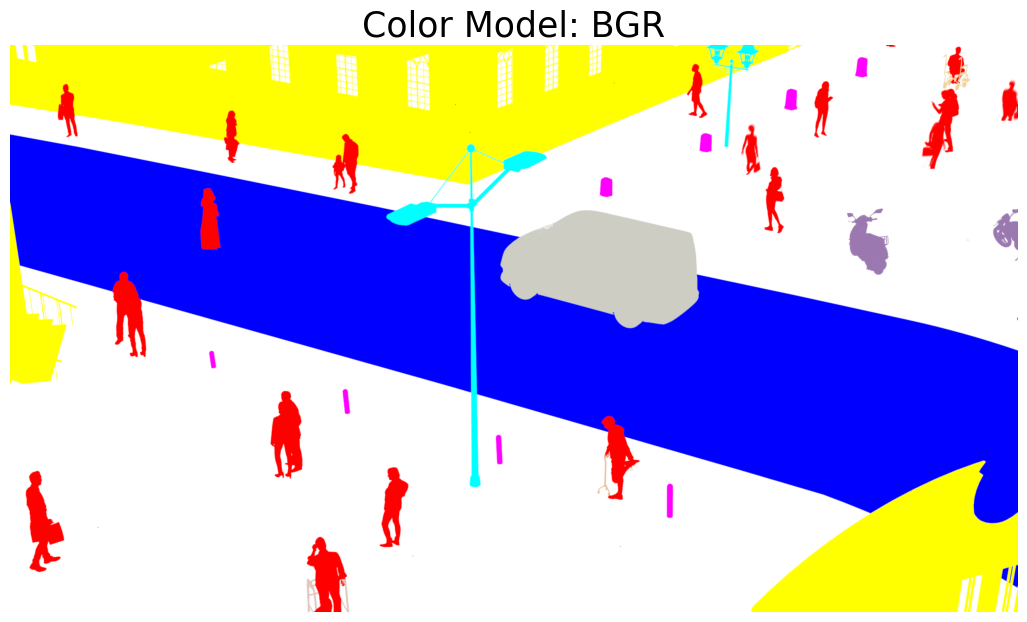

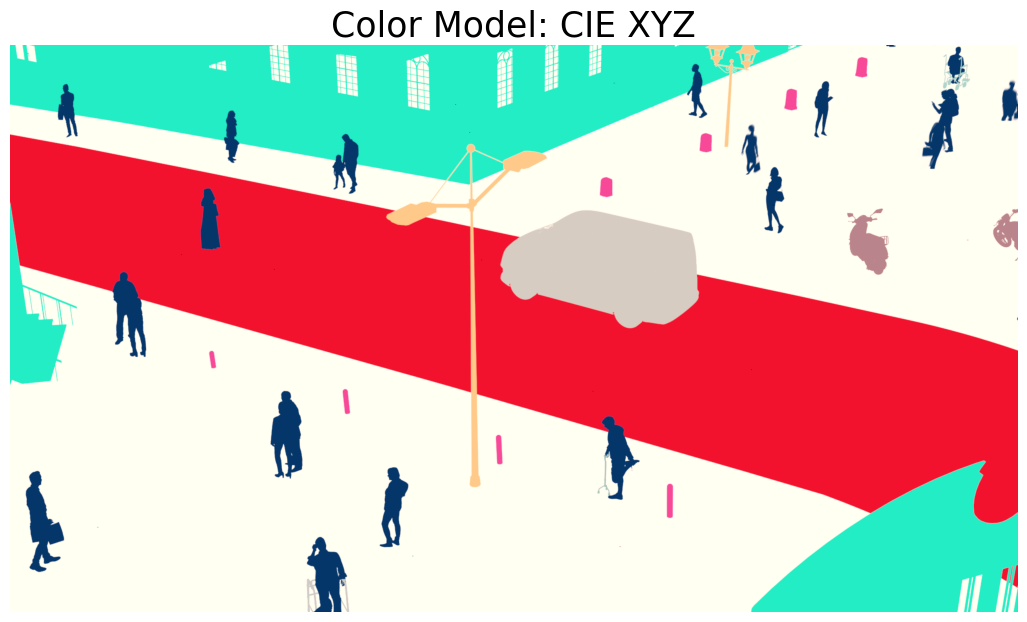

In [6]:
# Plotando a imagem usando o modelo de cor CIE XYZ
plt.figure(figsize=[13,13])
plt.imshow(img[:,:,::-1])
plt.title("Color Model: BGR",fontdict={'fontsize': 25})
plt.axis('off')

plt.figure(figsize=[13,13])
plt.imshow(img_xyz[:,:,::-1])
plt.title("Color Model: CIE XYZ",fontdict={'fontsize': 25})
plt.axis('off')

In [9]:
import cv2 as cv
import numpy as np

# Passo 1: Converter de XYZ para RGB
xyz_color = np.array([[[0.6118, 0.6157, 0.5569]]], dtype=np.float32)

# OpenCV espera os valores de XYZ em uma escala de 0 a 1, então normalmente não é necessária uma conversão extra aqui
rgb_color = cv.cvtColor(xyz_color, cv.COLOR_XYZ2RGB)

# Passo 2: Converter de RGB para HSV
# OpenCV espera os valores de RGB em uma escala de 0 a 1, então já estamos prontos para a conversão.
hsv_color = cv.cvtColor(rgb_color, cv.COLOR_RGB2HSV)

# Exibir o resultado
print(f"XYZ Color: {xyz_color[0][0]}")
print(f"RGB Color: {rgb_color[0][0]}")
print(f"HSV Color: {hsv_color[0][0]}")


XYZ Color: [0.6118 0.6157 0.5569]
RGB Color: [0.7584677  0.58519936 0.49723274]
HSV Color: [20.204016    0.34442458  0.7584677 ]


In [10]:
# Alternative to Inspect the Color Values for each Pixel
cv.imshow("XYZ Image", img_xyz)
cv.waitKey(0)
cv.destroyAllWindows()